# CBIS-DDSM Preprocessing + Lesion Visualization Notebook

This notebook runs the preprocessing pipeline and then lesion feature visualization.
It includes intermediate checks so you can verify every step.

In [1]:
import sys, os
print(sys.executable)  # should point to ...\breast_cancer_screening\.venv\Scripts\python.exe
print(os.getcwd())

e:\Programok\msc_bme\harmadik_felev\hdmi_lab\breast_cancer_screening\.venv\Scripts\python.exe
e:\Programok\msc_bme\harmadik_felev\hdmi_lab\breast_cancer_screening


In [2]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import PreprocessConfig, Representation
from preprocess import MammogramPreprocessor
from dataset import build_sample_index
from lesion_analysis import (
    AnalysisInputs,
    _extract_single_lesion_features,
    run_full_analysis,
)

plt.style.use('default')

In [3]:
# Paths
DATA_ROOT = Path('./data/cbis-ddsm')
TRAIN_CSV = Path('./meta/cbis-ddsm/mass_case_description_train_set.csv')
TEST_CSV = Path('./meta/cbis-ddsm/mass_case_description_test_set.csv')
OUTPUT_DIR = Path('./outputs/notebook')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('DATA_ROOT exists:', DATA_ROOT.exists())
print('TRAIN_CSV exists:', TRAIN_CSV.exists())
print('TEST_CSV exists:', TEST_CSV.exists())

train_images = sorted((DATA_ROOT / 'train' / 'images').glob('*.png'))
train_masks = sorted((DATA_ROOT / 'train' / 'masks').glob('*.png'))
print('Train images:', len(train_images))
print('Train masks:', len(train_masks))

DATA_ROOT exists: True
TRAIN_CSV exists: True
TEST_CSV exists: True
Train images: 2353
Train masks: 2797


Indexed train samples: 1166
Indexed test samples: 348
Sample image key: P_00001_LEFT_CC
Sample #masks: 1


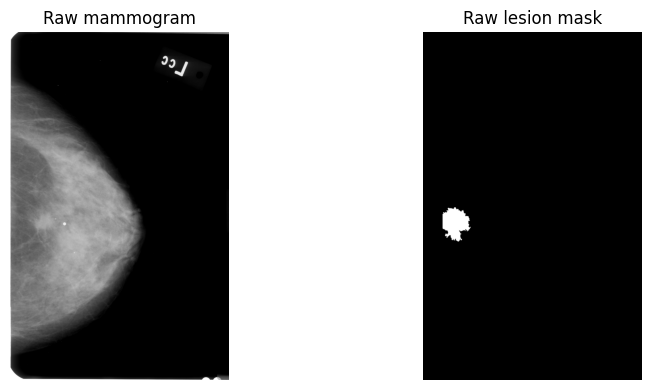

In [4]:
# Build sample index and inspect one sample
train_samples = build_sample_index(str(DATA_ROOT / 'train'), str(TRAIN_CSV))
test_samples = build_sample_index(str(DATA_ROOT / 'test'), str(TEST_CSV))

print('Indexed train samples:', len(train_samples))
print('Indexed test samples:', len(test_samples))

sample = train_samples[0]
print('Sample image key:', sample['image_key'])
print('Sample #masks:', len(sample['masks']))

raw_img = cv2.imread(sample['image_path'], cv2.IMREAD_GRAYSCALE)
raw_mask = cv2.imread(sample['masks'][0]['path'], cv2.IMREAD_GRAYSCALE)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(raw_img, cmap='gray')
ax[0].set_title('Raw mammogram')
ax[0].axis('off')

ax[1].imshow(raw_mask, cmap='gray')
ax[1].set_title('Raw lesion mask')
ax[1].axis('off')
plt.tight_layout()
plt.show()

Preprocessed image shape: (1024, 800, 3)
Preprocessed image range: 0.0 1.0000001192092896
Transformed mask nonzero: 6193


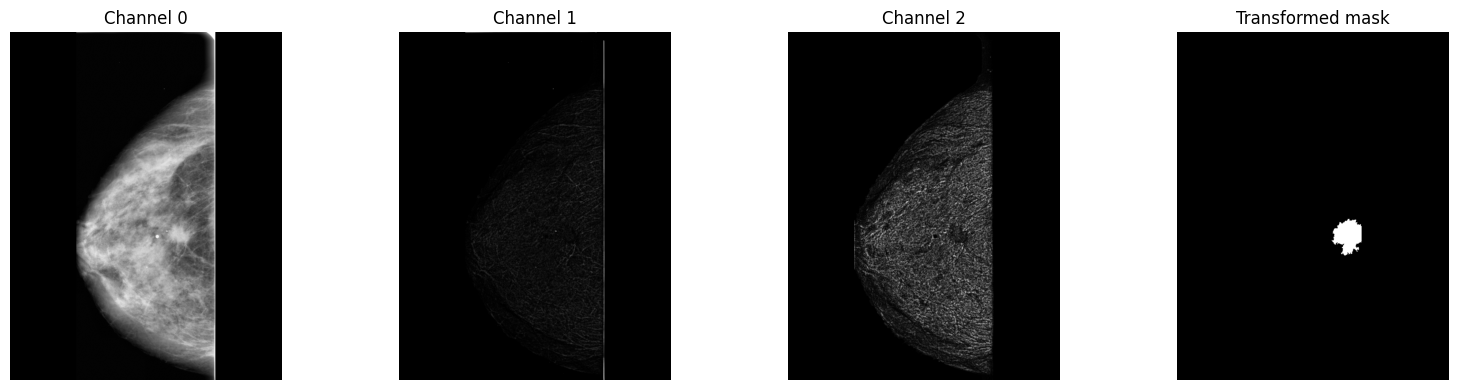

In [5]:
# Run preprocessing on one sample (including mask transform)
cfg = PreprocessConfig(
    representation=Representation.PSEUDO_COLOR,
    target_size=(1024, 800),
    orient_breast=True,
    tight_crop=True,
    remove_pectoral=True,
)
proc = MammogramPreprocessor(cfg)

img_3ch, tx = proc(raw_img, view=sample['view'])
mask_tx = proc.transform_mask((raw_mask > 127).astype(np.uint8) * 255, tx)

print('Preprocessed image shape:', img_3ch.shape)
print('Preprocessed image range:', float(img_3ch.min()), float(img_3ch.max()))
print('Transformed mask nonzero:', int((mask_tx > 0).sum()))

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(img_3ch[..., 0], cmap='gray')
ax[0].set_title('Channel 0')
ax[0].axis('off')
ax[1].imshow(img_3ch[..., 1], cmap='gray')
ax[1].set_title('Channel 1')
ax[1].axis('off')
ax[2].imshow(img_3ch[..., 2], cmap='gray')
ax[2].set_title('Channel 2')
ax[2].axis('off')
ax[3].imshow(mask_tx, cmap='gray')
ax[3].set_title('Transformed mask')
ax[3].axis('off')
plt.tight_layout()
plt.show()

In [6]:
# Quick quality checks
assert img_3ch.ndim == 3 and img_3ch.shape[2] == 3, 'Expected 3-channel image'
assert -1e-6 <= img_3ch.min() <= 1.0 + 1e-6, 'Unexpected min value'
assert -1e-6 <= img_3ch.max() <= 1.0 + 1e-6, 'Unexpected max value'
assert mask_tx.shape[:2] == img_3ch.shape[:2], 'Mask/image shape mismatch'
assert (mask_tx > 0).sum() > 0, 'Mask is empty after transform'
print('Preprocessing checks passed.')

Preprocessing checks passed.


In [7]:
# Quick lesion feature extraction on a subset (for fast feedback)
def extract_quick_features(samples, split_name, max_images=30):
    rows = []
    for sample_item in samples[:max_images]:
        image = cv2.imread(sample_item['image_path'], cv2.IMREAD_GRAYSCALE)
        if image is None:
            continue
        for m in sample_item['masks']:
            mask = cv2.imread(m['path'], cv2.IMREAD_GRAYSCALE)
            if mask is None:
                continue
            rec = _extract_single_lesion_features(
                image=image,
                mask=mask,
                split=split_name,
                image_key=sample_item['image_key'],
                patient_id=sample_item['patient_id'],
                side=sample_item['side'],
                view=sample_item['view'],
                pathology=m.get('pathology', 'UNKNOWN'),
                assessment=m.get('assessment', 0),
                mask_path=m['path'],
            )
            if rec is not None:
                rows.append(rec)
    return pd.DataFrame(rows)

df_quick_train = extract_quick_features(train_samples, 'train', max_images=30)
df_quick_test = extract_quick_features(test_samples, 'test', max_images=30)
df_quick = pd.concat([df_quick_train, df_quick_test], ignore_index=True)

print('Quick subset lesions:', len(df_quick))
display(df_quick.head())

Quick subset lesions: 66


,split,image_key,patient_id,side,view,pathology,assessment,mask_path,image_height,image_width,...,bbox_area_px,bbox_aspect_ratio,centroid_x,centroid_y,centroid_x_norm,centroid_y_norm,perimeter_px,compactness,solidity,boundary_clarity
0,train,P_00001_LEFT_CC,P_00001,LEFT,CC,MALIGNANT,4,data\cbis-ddsm\train\masks\P_00001_LEFT_CC_den...,4808,3024,...,185725,0.823158,444.374209,2640.358502,0.146949,0.549159,3085.887635,6.357134,0.822408,16.460642
1,train,P_00001_LEFT_MLO,P_00001,LEFT,MLO,MALIGNANT,4,data\cbis-ddsm\train\masks\P_00001_LEFT_MLO_de...,4800,2656,...,54432,0.857143,375.706227,3097.129286,0.141456,0.645235,1200.236710,3.616929,0.813754,16.133804
2,train,P_00004_LEFT_CC,P_00004,LEFT,CC,BENIGN,4,data\cbis-ddsm\train\masks\P_00004_LEFT_CC_den...,5491,2986,...,163158,0.899061,1613.065036,3710.092490,0.540209,0.675668,2766.321184,5.431067,0.848711,12.148972
3,train,P_00004_LEFT_MLO,P_00004,LEFT,MLO,BENIGN,4,data\cbis-ddsm\train\masks\P_00004_LEFT_MLO_de...,5491,3046,...,147834,0.987080,1843.975141,3247.664258,0.605376,0.591452,3002.002418,8.129243,0.792118,12.796502
4,train,P_00004_RIGHT_MLO,P_00004,RIGHT,MLO,BENIGN,4,data\cbis-ddsm\train\masks\P_00004_RIGHT_MLO_d...,5491,2911,...,152575,1.183844,914.435576,3973.968648,0.314131,0.723724,2394.372916,5.026684,0.832309,12.835183


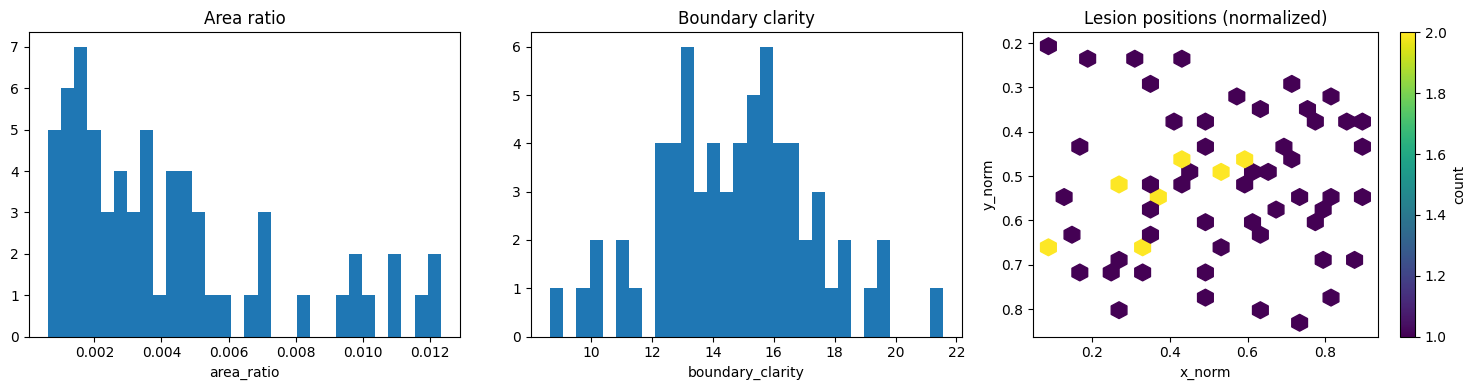

In [8]:
# Quick subset visualizations
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(df_quick['area_ratio'].dropna(), bins=30)
ax[0].set_title('Area ratio')
ax[0].set_xlabel('area_ratio')

ax[1].hist(df_quick['boundary_clarity'].dropna(), bins=30)
ax[1].set_title('Boundary clarity')
ax[1].set_xlabel('boundary_clarity')

hb = ax[2].hexbin(
    df_quick['centroid_x_norm'],
    df_quick['centroid_y_norm'],
    gridsize=20,
    mincnt=1,
    cmap='viridis'
)
ax[2].set_title('Lesion positions (normalized)')
ax[2].set_xlabel('x_norm')
ax[2].set_ylabel('y_norm')
ax[2].invert_yaxis()
fig.colorbar(hb, ax=ax[2], label='count')

plt.tight_layout()
plt.show()

In [9]:
# Full analysis on the complete dataset (can take a while)
inputs = AnalysisInputs(
    data_root=str(DATA_ROOT),
    train_csv=str(TRAIN_CSV),
    test_csv=str(TEST_CSV),
)
full_csv = OUTPUT_DIR / 'lesion_features_full.csv'
full_plot_dir = OUTPUT_DIR / 'plots_full'

df_full, plot_paths = run_full_analysis(
    inputs=inputs,
    output_csv=str(full_csv),
    output_dir=str(full_plot_dir),
)

print('Full lesions:', len(df_full))
print('Feature CSV:', full_csv)
print('Generated plots:')
for p in plot_paths:
    print(' -', p)
display(df_full.head())

Full lesions: 1618
Feature CSV: outputs\notebook\lesion_features_full.csv
Generated plots:
 - outputs\notebook\plots_full\hist_area_ratio.png
 - outputs\notebook\plots_full\hist_equiv_diameter_px.png
 - outputs\notebook\plots_full\hist_boundary_clarity.png
 - outputs\notebook\plots_full\hist_compactness.png
 - outputs\notebook\plots_full\hist_solidity.png
 - outputs\notebook\plots_full\lesion_position_hexbin.png


,split,image_key,patient_id,side,view,pathology,assessment,mask_path,image_height,image_width,...,bbox_area_px,bbox_aspect_ratio,centroid_x,centroid_y,centroid_x_norm,centroid_y_norm,perimeter_px,compactness,solidity,boundary_clarity
0,train,P_00001_LEFT_CC,P_00001,LEFT,CC,MALIGNANT,4,data\cbis-ddsm\train\masks\P_00001_LEFT_CC_den...,4808,3024,...,185725,0.823158,444.374209,2640.358502,0.146949,0.549159,3085.887635,6.357134,0.822408,16.460642
1,train,P_00001_LEFT_MLO,P_00001,LEFT,MLO,MALIGNANT,4,data\cbis-ddsm\train\masks\P_00001_LEFT_MLO_de...,4800,2656,...,54432,0.857143,375.706227,3097.129286,0.141456,0.645235,1200.236710,3.616929,0.813754,16.133804
2,train,P_00004_LEFT_CC,P_00004,LEFT,CC,BENIGN,4,data\cbis-ddsm\train\masks\P_00004_LEFT_CC_den...,5491,2986,...,163158,0.899061,1613.065036,3710.092490,0.540209,0.675668,2766.321184,5.431067,0.848711,12.148972
3,train,P_00004_LEFT_MLO,P_00004,LEFT,MLO,BENIGN,4,data\cbis-ddsm\train\masks\P_00004_LEFT_MLO_de...,5491,3046,...,147834,0.987080,1843.975141,3247.664258,0.605376,0.591452,3002.002418,8.129243,0.792118,12.796502
4,train,P_00004_RIGHT_MLO,P_00004,RIGHT,MLO,BENIGN,4,data\cbis-ddsm\train\masks\P_00004_RIGHT_MLO_d...,5491,2911,...,152575,1.183844,914.435576,3973.968648,0.314131,0.723724,2394.372916,5.026684,0.832309,12.835183


Plot file count: 6
hist_area_ratio.png


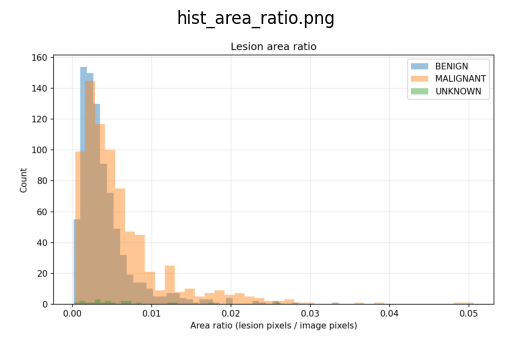

hist_boundary_clarity.png


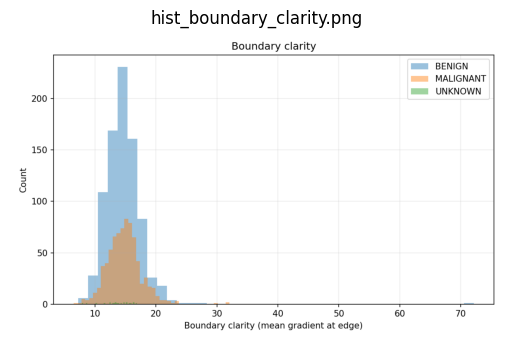

hist_compactness.png


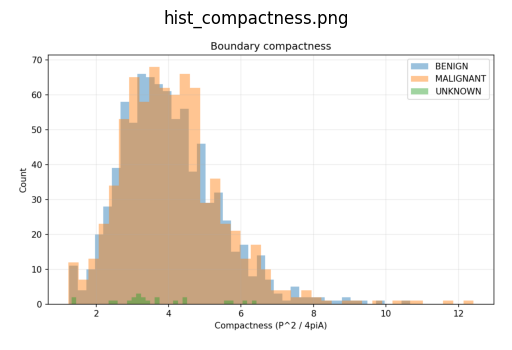

hist_equiv_diameter_px.png


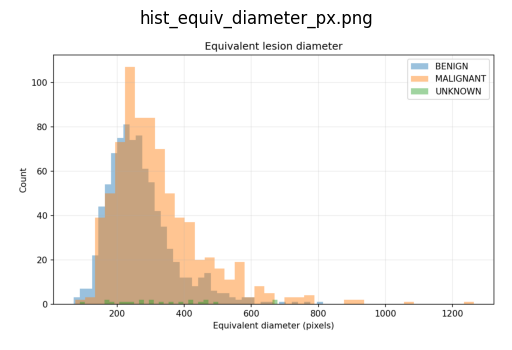

hist_solidity.png


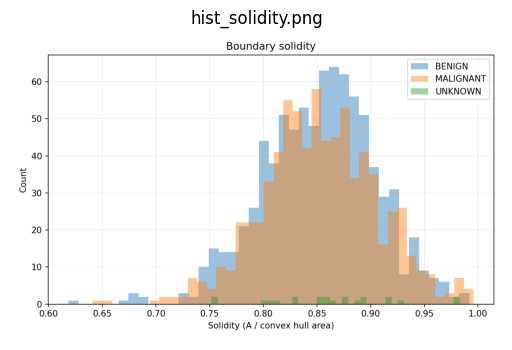

lesion_position_hexbin.png


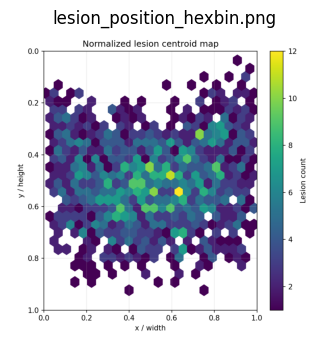

In [10]:
# Display generated plot files
plot_files = sorted((full_plot_dir).glob('*.png'))
print('Plot file count:', len(plot_files))

for pf in plot_files:
    print(pf.name)
    img = cv2.imread(str(pf))
    if img is None:
        continue
    plt.figure(figsize=(7, 4))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(pf.name)
    plt.axis('off')
    plt.show()

In [11]:
# Save full-dataset plots and requested extra diagrams
full_notebook_plot_dir = OUTPUT_DIR / 'plots_full_notebook'
full_notebook_plot_dir.mkdir(parents=True, exist_ok=True)
extra_plot_dir = OUTPUT_DIR / 'plots_full_extra'
extra_plot_dir.mkdir(parents=True, exist_ok=True)
saved_paths = []

# 1) Combined full-dataset histograms from df_full
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
ax = ax.ravel()

ax[0].hist(df_full['area_ratio'].dropna(), bins=40)
ax[0].set_title('Full dataset: area_ratio')
ax[0].set_xlabel('area_ratio')
ax[0].set_ylabel('count')

ax[1].hist(df_full['equiv_diameter_px'].dropna(), bins=40)
ax[1].set_title('Full dataset: equiv_diameter_px')
ax[1].set_xlabel('equiv_diameter_px')
ax[1].set_ylabel('count')

ax[2].hist(df_full['boundary_clarity'].dropna(), bins=40)
ax[2].set_title('Full dataset: boundary_clarity')
ax[2].set_xlabel('boundary_clarity')
ax[2].set_ylabel('count')

ax[3].hist(df_full['solidity'].dropna(), bins=40)
ax[3].set_title('Full dataset: solidity')
ax[3].set_xlabel('solidity')
ax[3].set_ylabel('count')

fig.tight_layout()
combined_hist_path = full_notebook_plot_dir / 'full_dataset_histograms.png'
fig.savefig(combined_hist_path, dpi=150)
plt.close(fig)
saved_paths.append(combined_hist_path)

# 2) Save full-dataset centroid hexbin
fig, ax = plt.subplots(figsize=(7, 6))
hb = ax.hexbin(
    df_full['centroid_x_norm'],
    df_full['centroid_y_norm'],
    gridsize=30,
    mincnt=1,
    cmap='viridis'
)
fig.colorbar(hb, ax=ax, label='lesion count')
ax.set_title('Full dataset lesion centroid map')
ax.set_xlabel('centroid_x_norm')
ax.set_ylabel('centroid_y_norm')
ax.invert_yaxis()
fig.tight_layout()
centroid_map_path = full_notebook_plot_dir / 'full_dataset_centroid_hexbin.png'
fig.savefig(centroid_map_path, dpi=150)
plt.close(fig)
saved_paths.append(centroid_map_path)

# 3) Dataset size summary
train_image_count = len(list((DATA_ROOT / 'train' / 'images').glob('*.png')))
test_image_count = len(list((DATA_ROOT / 'test' / 'images').glob('*.png')))
train_mask_count = len(list((DATA_ROOT / 'train' / 'masks').glob('*.png')))
test_mask_count = len(list((DATA_ROOT / 'test' / 'masks').glob('*.png')))

dataset_summary = pd.DataFrame(
    [
        {'split': 'train', 'images': train_image_count, 'masks': train_mask_count},
        {'split': 'test', 'images': test_image_count, 'masks': test_mask_count},
    ]
)
dataset_summary['indexed_images_with_mass'] = [len(train_samples), len(test_samples)]
dataset_summary['lesions_in_df_full'] = [
    int((df_full['split'] == 'train').sum()),
    int((df_full['split'] == 'test').sum()),
]
dataset_summary['patients_with_mass'] = [
    int(pd.Series([s['patient_id'] for s in train_samples]).nunique()),
    int(pd.Series([s['patient_id'] for s in test_samples]).nunique()),
]
display(dataset_summary)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].bar(dataset_summary['split'], dataset_summary['images'])
ax[0].set_title('Images per split')
ax[0].set_ylabel('count')
ax[1].bar(dataset_summary['split'], dataset_summary['masks'])
ax[1].set_title('Mask files per split')
ax[1].set_ylabel('count')
ax[2].bar(dataset_summary['split'], dataset_summary['lesions_in_df_full'])
ax[2].set_title('Lesions in df_full per split')
ax[2].set_ylabel('count')
fig.tight_layout()
summary_path = extra_plot_dir / 'dataset_size_summary.png'
fig.savefig(summary_path, dpi=150)
plt.close(fig)
saved_paths.append(summary_path)

# 4) Images per patient (all images vs indexed mass images)
all_image_paths = list((DATA_ROOT / 'train' / 'images').glob('*.png')) + list((DATA_ROOT / 'test' / 'images').glob('*.png'))
all_patient_ids = ['_'.join(p.stem.split('_')[:2]) for p in all_image_paths]
all_images_per_patient = pd.Series(all_patient_ids).value_counts().sort_values(ascending=False)

indexed_train_patient_ids = [s['patient_id'] for s in train_samples]
indexed_test_patient_ids = [s['patient_id'] for s in test_samples]
indexed_images_per_patient = pd.Series(indexed_train_patient_ids + indexed_test_patient_ids).value_counts().sort_values(ascending=False)

print('All images total:', len(all_image_paths))
print('Unique patients (all images):', int(all_images_per_patient.shape[0]))
print('Indexed images total:', len(indexed_train_patient_ids) + len(indexed_test_patient_ids))
print('Unique patients (indexed):', int(indexed_images_per_patient.shape[0]))
display(pd.DataFrame({
    'all_images_per_patient': all_images_per_patient.head(15),
    'indexed_images_per_patient': indexed_images_per_patient.head(15)
}))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(all_images_per_patient.values, bins=np.arange(0.5, all_images_per_patient.max() + 1.5, 1))
ax[0].set_title('All images per patient')
ax[0].set_xlabel('images / patient')
ax[0].set_ylabel('patient count')

ax[1].hist(indexed_images_per_patient.values, bins=np.arange(0.5, indexed_images_per_patient.max() + 1.5, 1))
ax[1].set_title('Indexed mass images per patient')
ax[1].set_xlabel('indexed images / patient')
ax[1].set_ylabel('patient count')

fig.tight_layout()
per_patient_path = extra_plot_dir / 'images_per_patient_distribution.png'
fig.savefig(per_patient_path, dpi=150)
plt.close(fig)
saved_paths.append(per_patient_path)

# 5) Enrich with density and compute lesion-surrounding contrast
sample_rows = []
for split_name, samples in [('train', train_samples), ('test', test_samples)]:
    for s in samples:
        for m in s['masks']:
            sample_rows.append({
                'split': split_name,
                'image_key': s['image_key'],
                'mask_path': m['path'],
                'image_path': s['image_path'],
                'density': s['density'],
            })

sample_info = pd.DataFrame(sample_rows)
df_plot = df_full.merge(sample_info, on=['split', 'image_key', 'mask_path'], how='left')

def lesion_surrounding_contrast(image_path, mask_path, ring_width=15):
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if image is None or mask is None:
        return np.nan, np.nan, np.nan
    lesion = (mask > 127).astype(np.uint8)
    if lesion.sum() == 0:
        return np.nan, np.nan, np.nan
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * ring_width + 1, 2 * ring_width + 1))
    dilated = cv2.dilate(lesion, kernel, iterations=1)
    ring = ((dilated > 0) & (lesion == 0)).astype(np.uint8)
    if ring.sum() == 0:
        return np.nan, np.nan, np.nan
    lesion_mean = float(image[lesion > 0].mean())
    ring_mean = float(image[ring > 0].mean())
    diff_signed = float(lesion_mean - ring_mean)
    return lesion_mean, ring_mean, diff_signed

contrast_vals = [lesion_surrounding_contrast(ip, mp) for ip, mp in zip(df_plot['image_path'], df_plot['mask_path'])]
df_plot['lesion_mean_intensity'] = [v[0] for v in contrast_vals]
df_plot['surrounding_mean_intensity'] = [v[1] for v in contrast_vals]
df_plot['contrast_diff_signed'] = [v[2] for v in contrast_vals]
df_plot['contrast_diff_abs'] = df_plot['contrast_diff_signed'].abs()

# 6) Requested extra diagrams
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_plot['area_ratio'].dropna(), bins=50)
ax.set_title('Lesion size distribution (area_ratio)')
ax.set_xlabel('area_ratio')
ax.set_ylabel('count')
fig.tight_layout()
p1 = extra_plot_dir / 'lesion_size_hist_area_ratio.png'
fig.savefig(p1, dpi=150)
plt.close(fig)
saved_paths.append(p1)

fig, ax = plt.subplots(figsize=(6, 6))
hb = ax.hexbin(df_plot['centroid_x_norm'], df_plot['centroid_y_norm'], gridsize=30, mincnt=1, cmap='viridis')
fig.colorbar(hb, ax=ax, label='lesion count')
ax.set_title('Lesion location (normalized coordinates)')
ax.set_xlabel('centroid_x_norm')
ax.set_ylabel('centroid_y_norm')
ax.invert_yaxis()
fig.tight_layout()
p2 = extra_plot_dir / 'lesion_location_hexbin_normalized.png'
fig.savefig(p2, dpi=150)
plt.close(fig)
saved_paths.append(p2)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_plot['contrast_diff_abs'].dropna(), bins=50)
ax.set_title('Lesion vs surrounding contrast difference (absolute)')
ax.set_xlabel('abs(lesion_mean - surrounding_mean)')
ax.set_ylabel('count')
fig.tight_layout()
p3 = extra_plot_dir / 'lesion_surrounding_contrast_diff_hist.png'
fig.savefig(p3, dpi=150)
plt.close(fig)
saved_paths.append(p3)

density_counts = df_plot['density'].value_counts(dropna=True).sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(density_counts.index.astype(str), density_counts.values)
ax.set_title('Breast density distribution')
ax.set_xlabel('density category')
ax.set_ylabel('lesion count')
fig.tight_layout()
p4 = extra_plot_dir / 'density_distribution.png'
fig.savefig(p4, dpi=150)
plt.close(fig)
saved_paths.append(p4)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
view_counts = df_plot['view'].value_counts()
side_counts = df_plot['side'].value_counts()
path_counts = df_plot['pathology'].value_counts()
ax[0].bar(view_counts.index.astype(str), view_counts.values)
ax[0].set_title('View distribution')
ax[0].set_ylabel('lesion count')
ax[1].bar(side_counts.index.astype(str), side_counts.values)
ax[1].set_title('Side distribution')
ax[2].bar(path_counts.index.astype(str), path_counts.values)
ax[2].set_title('Pathology distribution')
fig.tight_layout()
p5 = extra_plot_dir / 'view_side_pathology_distribution.png'
fig.savefig(p5, dpi=150)
plt.close(fig)
saved_paths.append(p5)

# 7) Also include files generated by run_full_analysis
for p in sorted(full_plot_dir.glob('*.png')):
    saved_paths.append(p)

print('Saved/available full-dataset plot files:')
for p in saved_paths:
    print(' -', p)

,split,images,masks,indexed_images_with_mass,lesions_in_df_full,patients_with_mass
0,train,2353,2797,1166,1253,657
1,test,627,688,348,365,196


All images total: 2980
Unique patients (all images): 1527
Indexed images total: 1514
Unique patients (indexed): 853


,all_images_per_patient,indexed_images_per_patient
P_00008,4.0,NaN
P_00016,4.0,NaN
P_00021,4.0,4.0
P_00030,4.0,NaN
P_00041,4.0,NaN
P_00092,4.0,4.0
P_00098,4.0,NaN
P_00106,4.0,4.0
P_00112,4.0,NaN
P_00160,4.0,4.0


Saved/available full-dataset plot files:
 - outputs\notebook\plots_full_notebook\full_dataset_histograms.png
 - outputs\notebook\plots_full_notebook\full_dataset_centroid_hexbin.png
 - outputs\notebook\plots_full_extra\dataset_size_summary.png
 - outputs\notebook\plots_full_extra\images_per_patient_distribution.png
 - outputs\notebook\plots_full_extra\lesion_size_hist_area_ratio.png
 - outputs\notebook\plots_full_extra\lesion_location_hexbin_normalized.png
 - outputs\notebook\plots_full_extra\lesion_surrounding_contrast_diff_hist.png
 - outputs\notebook\plots_full_extra\density_distribution.png
 - outputs\notebook\plots_full_extra\view_side_pathology_distribution.png
 - outputs\notebook\plots_full\hist_area_ratio.png
 - outputs\notebook\plots_full\hist_boundary_clarity.png
 - outputs\notebook\plots_full\hist_compactness.png
 - outputs\notebook\plots_full\hist_equiv_diameter_px.png
 - outputs\notebook\plots_full\hist_solidity.png
 - outputs\notebook\plots_full\lesion_position_hexbin.png